# Exploring `mujoco/invertedpendulum/expert-v0` with Minari

This notebook loads the Minari expert dataset for the MuJoCo InvertedPendulum environment,
assembles a **100 000 × 5** observation-action matrix, and lays the groundwork for training
a Self-Organizing Map (SOM) on the resulting data.

| Column index | Description |
|---|---|
| 0 | Cart position |
| 1 | Cart velocity |
| 2 | Pole angle |
| 3 | Pole angular velocity |
| 4 | Action (force applied to cart) |

## Install Dependencies & Load Imports

In [1]:
%pip install numpy "minari[hf]" minisom scikit-learn scipy matplotlib

import numpy as np
import minari
from minisom import MiniSom
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Load dataset

If the dataset has not been downloaded yet, Minari will fetch it automatically from the remote
registry the first time `load_dataset` is called.

In [2]:
DATASET_ID_EXPERT = "mujoco/invertedpendulum/expert-v0"
DATASET_ID_MEDIUM = "mujoco/invertedpendulum/medium-v0"

# Download if not already cached locally
if DATASET_ID_EXPERT not in minari.list_local_datasets():
    minari.download_dataset(DATASET_ID_EXPERT)

dataset_expert = minari.load_dataset(DATASET_ID_EXPERT)
print(f"Dataset loaded: {DATASET_ID_EXPERT}")
print(f"Total episodes : {dataset_expert.total_episodes}")
print(f"Total steps    : {dataset_expert.total_steps}")

if DATASET_ID_MEDIUM not in minari.list_local_datasets():
    minari.download_dataset(DATASET_ID_MEDIUM)  
dataset_medium = minari.load_dataset(DATASET_ID_MEDIUM)
print(f"Dataset loaded: {DATASET_ID_MEDIUM}")
print(f"Total episodes : {dataset_medium.total_episodes}")
print(f"Total steps    : {dataset_medium.total_steps}")

Dataset loaded: mujoco/invertedpendulum/expert-v0
Total episodes : 100
Total steps    : 100000
Dataset loaded: mujoco/invertedpendulum/medium-v0
Total episodes : 1040
Total steps    : 99075


## Initialize combined numpy matrix for all observations

In [3]:
obs_list = []

for episode in dataset_expert.iterate_episodes():
    obs = episode.observations
    obs_list.append(obs[:-1])  # drop terminal observation

for episode in dataset_medium.iterate_episodes():
    obs = episode.observations
    obs_list.append(obs[:-1])

all_observations = np.concatenate(obs_list, axis=0)
print("all_observations shape:", all_observations.shape)

all_observations shape: (199075, 4)


## Statistical Analysis of Raw Observations

Column                    Min        Max       Mean        Std     Median       Skew       Kurt
----------------------------------------------------------------------------------------------------
cart_pos              -1.0298     1.0312    -0.0483     0.2856    -0.0799     0.3098     4.3163
cart_vel              -0.2000     0.2000    -0.0000     0.0411    -0.0006     0.0753     2.4798
pole_angle            -2.0366     1.9588     0.0035     0.4168     0.0057     0.0298     1.1511
pole_ang_vel          -3.3846     3.1573     0.0011     0.7489    -0.0074     0.0601     0.5001


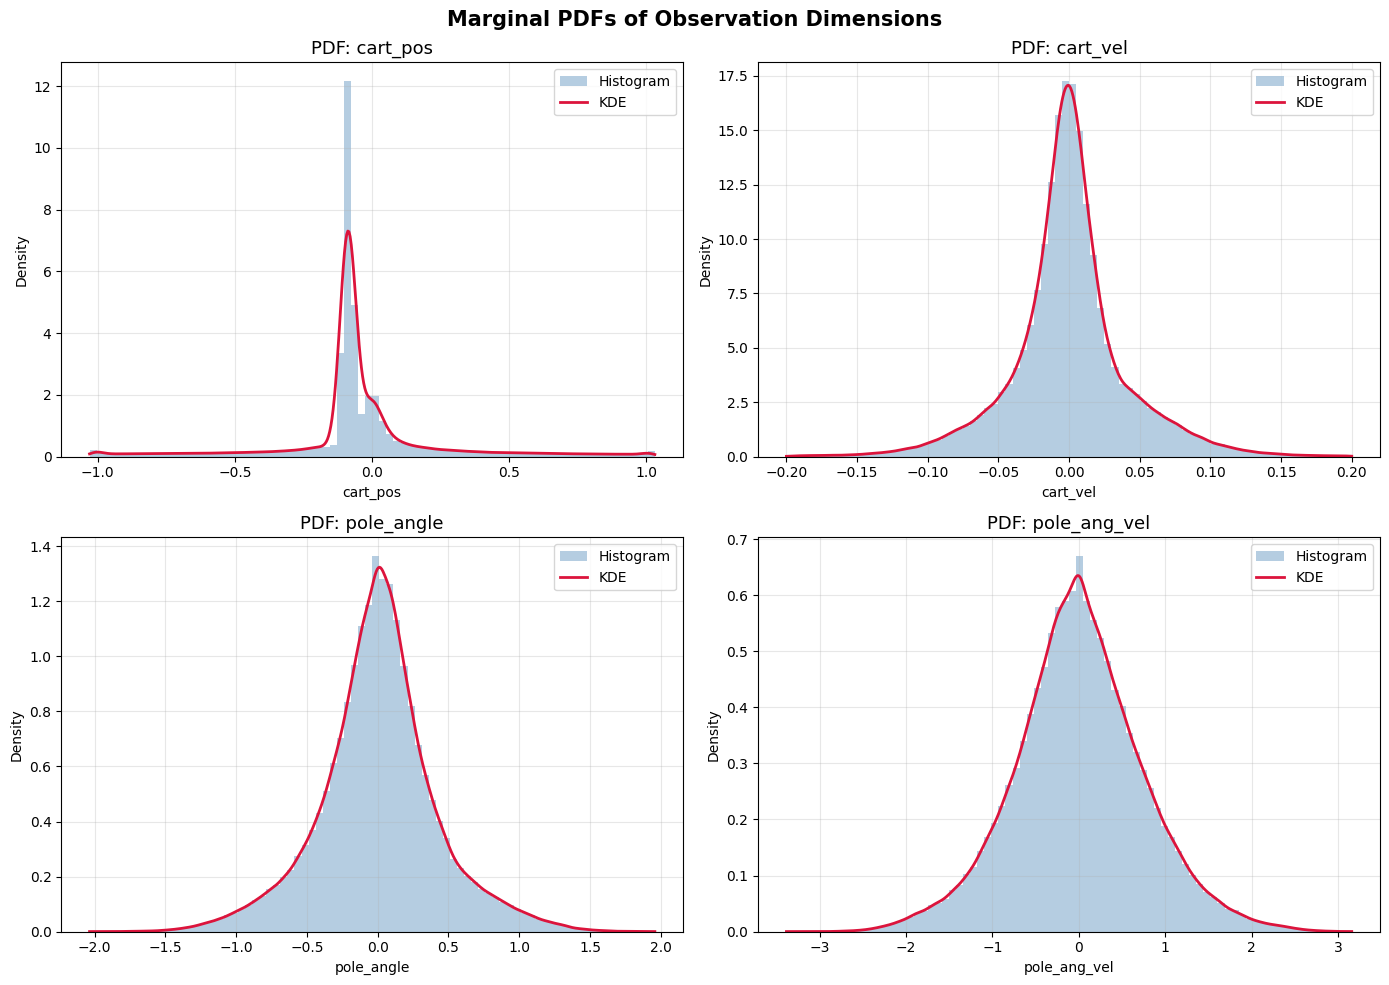

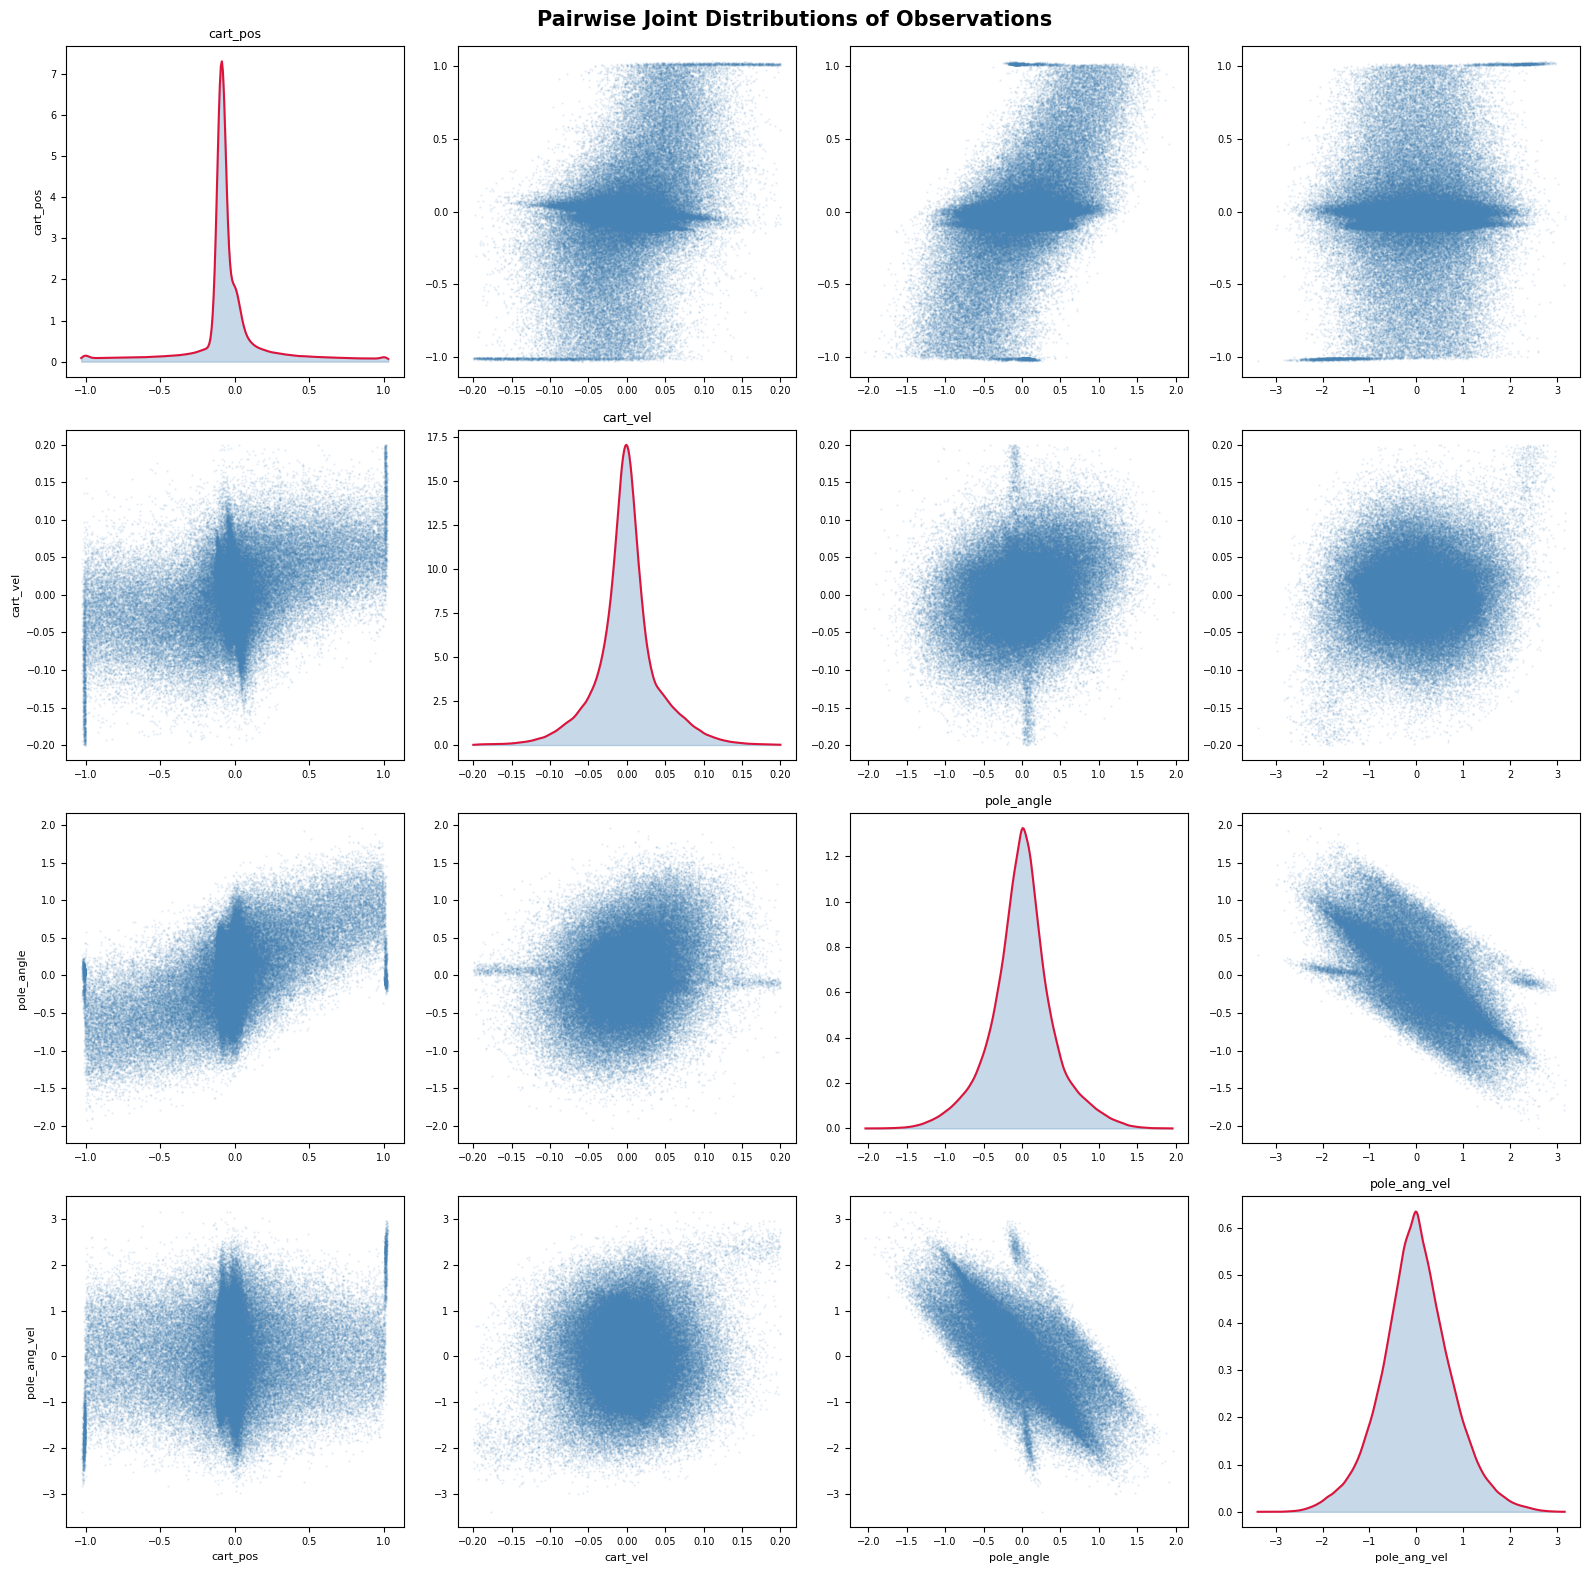

In [4]:
COL_NAMES = ["cart_pos", "cart_vel", "pole_angle", "pole_ang_vel"]

# --- Statistics ---
print(f"{'Column':<18} {'Min':>10} {'Max':>10} {'Mean':>10} {'Std':>10} {'Median':>10} {'Skew':>10} {'Kurt':>10}")
print("-" * 100)
for i, name in enumerate(COL_NAMES):
    col = all_observations[:, i]
    print(f"{name:<18} {col.min():>10.4f} {col.max():>10.4f} {col.mean():>10.4f} "
          f"{col.std():>10.4f} {np.median(col):>10.4f} {skew(col):>10.4f} {kurtosis(col):>10.4f}")

# --- PDF Visualizations ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, ax) in enumerate(zip(COL_NAMES, axes)):
    col = all_observations[:, i]
    kde = gaussian_kde(col)
    x = np.linspace(col.min(), col.max(), 500)
    ax.hist(col, bins=80, density=True, alpha=0.4, color="steelblue", label="Histogram")
    ax.plot(x, kde(x), color="crimson", linewidth=2, label="KDE")
    ax.set_title(f"PDF: {name}", fontsize=13)
    ax.set_xlabel(name)
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Marginal PDFs of Observation Dimensions", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Pairplot-style joint scatter with KDE marginals ---
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for i in range(4):
    for j in range(4):
        ax = axes[i, j]
        if i == j:
            col = all_observations[:, i]
            kde = gaussian_kde(col)
            x = np.linspace(col.min(), col.max(), 300)
            ax.plot(x, kde(x), color="crimson")
            ax.fill_between(x, kde(x), alpha=0.3, color="steelblue")
            ax.set_title(COL_NAMES[i], fontsize=9)
        else:
            ax.scatter(all_observations[:, j], all_observations[:, i],
                       s=0.5, alpha=0.1, color="steelblue")
        if i == 3:
            ax.set_xlabel(COL_NAMES[j], fontsize=8)
        if j == 0:
            ax.set_ylabel(COL_NAMES[i], fontsize=8)
        ax.tick_params(labelsize=7)

plt.suptitle("Pairwise Joint Distributions of Observations", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## Initialize scaled_observations

In [5]:
scaler = StandardScaler()
scaled_observations = scaler.fit_transform(all_observations)
print("scaled_observations shape:", scaled_observations.shape)
print("means:", scaled_observations.mean(axis=0))
print("stds:", scaled_observations.std(axis=0))

scaled_observations shape: (199075, 4)
means: [-2.61960545e-15 -1.98736474e-16  1.31706550e-16 -3.99083560e-18]
stds: [1. 1. 1. 1.]


## Initialize 'instruction' vector

In [6]:
# Target state is the subset of the input space where the pole is near vertical (angle close to 0)
threshold = 0.025

# Pole angle is the 3rd column (index 2) of the observations
instruction = (np.abs(all_observations[:, 2]) <= threshold).astype(np.float32).reshape(-1, 1)

print("instruction shape:", instruction.shape)
print("num ones:", int(instruction.sum()), "num zeros:", instruction.shape[0] - int(instruction.sum()))

instruction shape: (199075, 1)
num ones: 13719 num zeros: 185356


## Joint Probabilities of Observations & Instruction

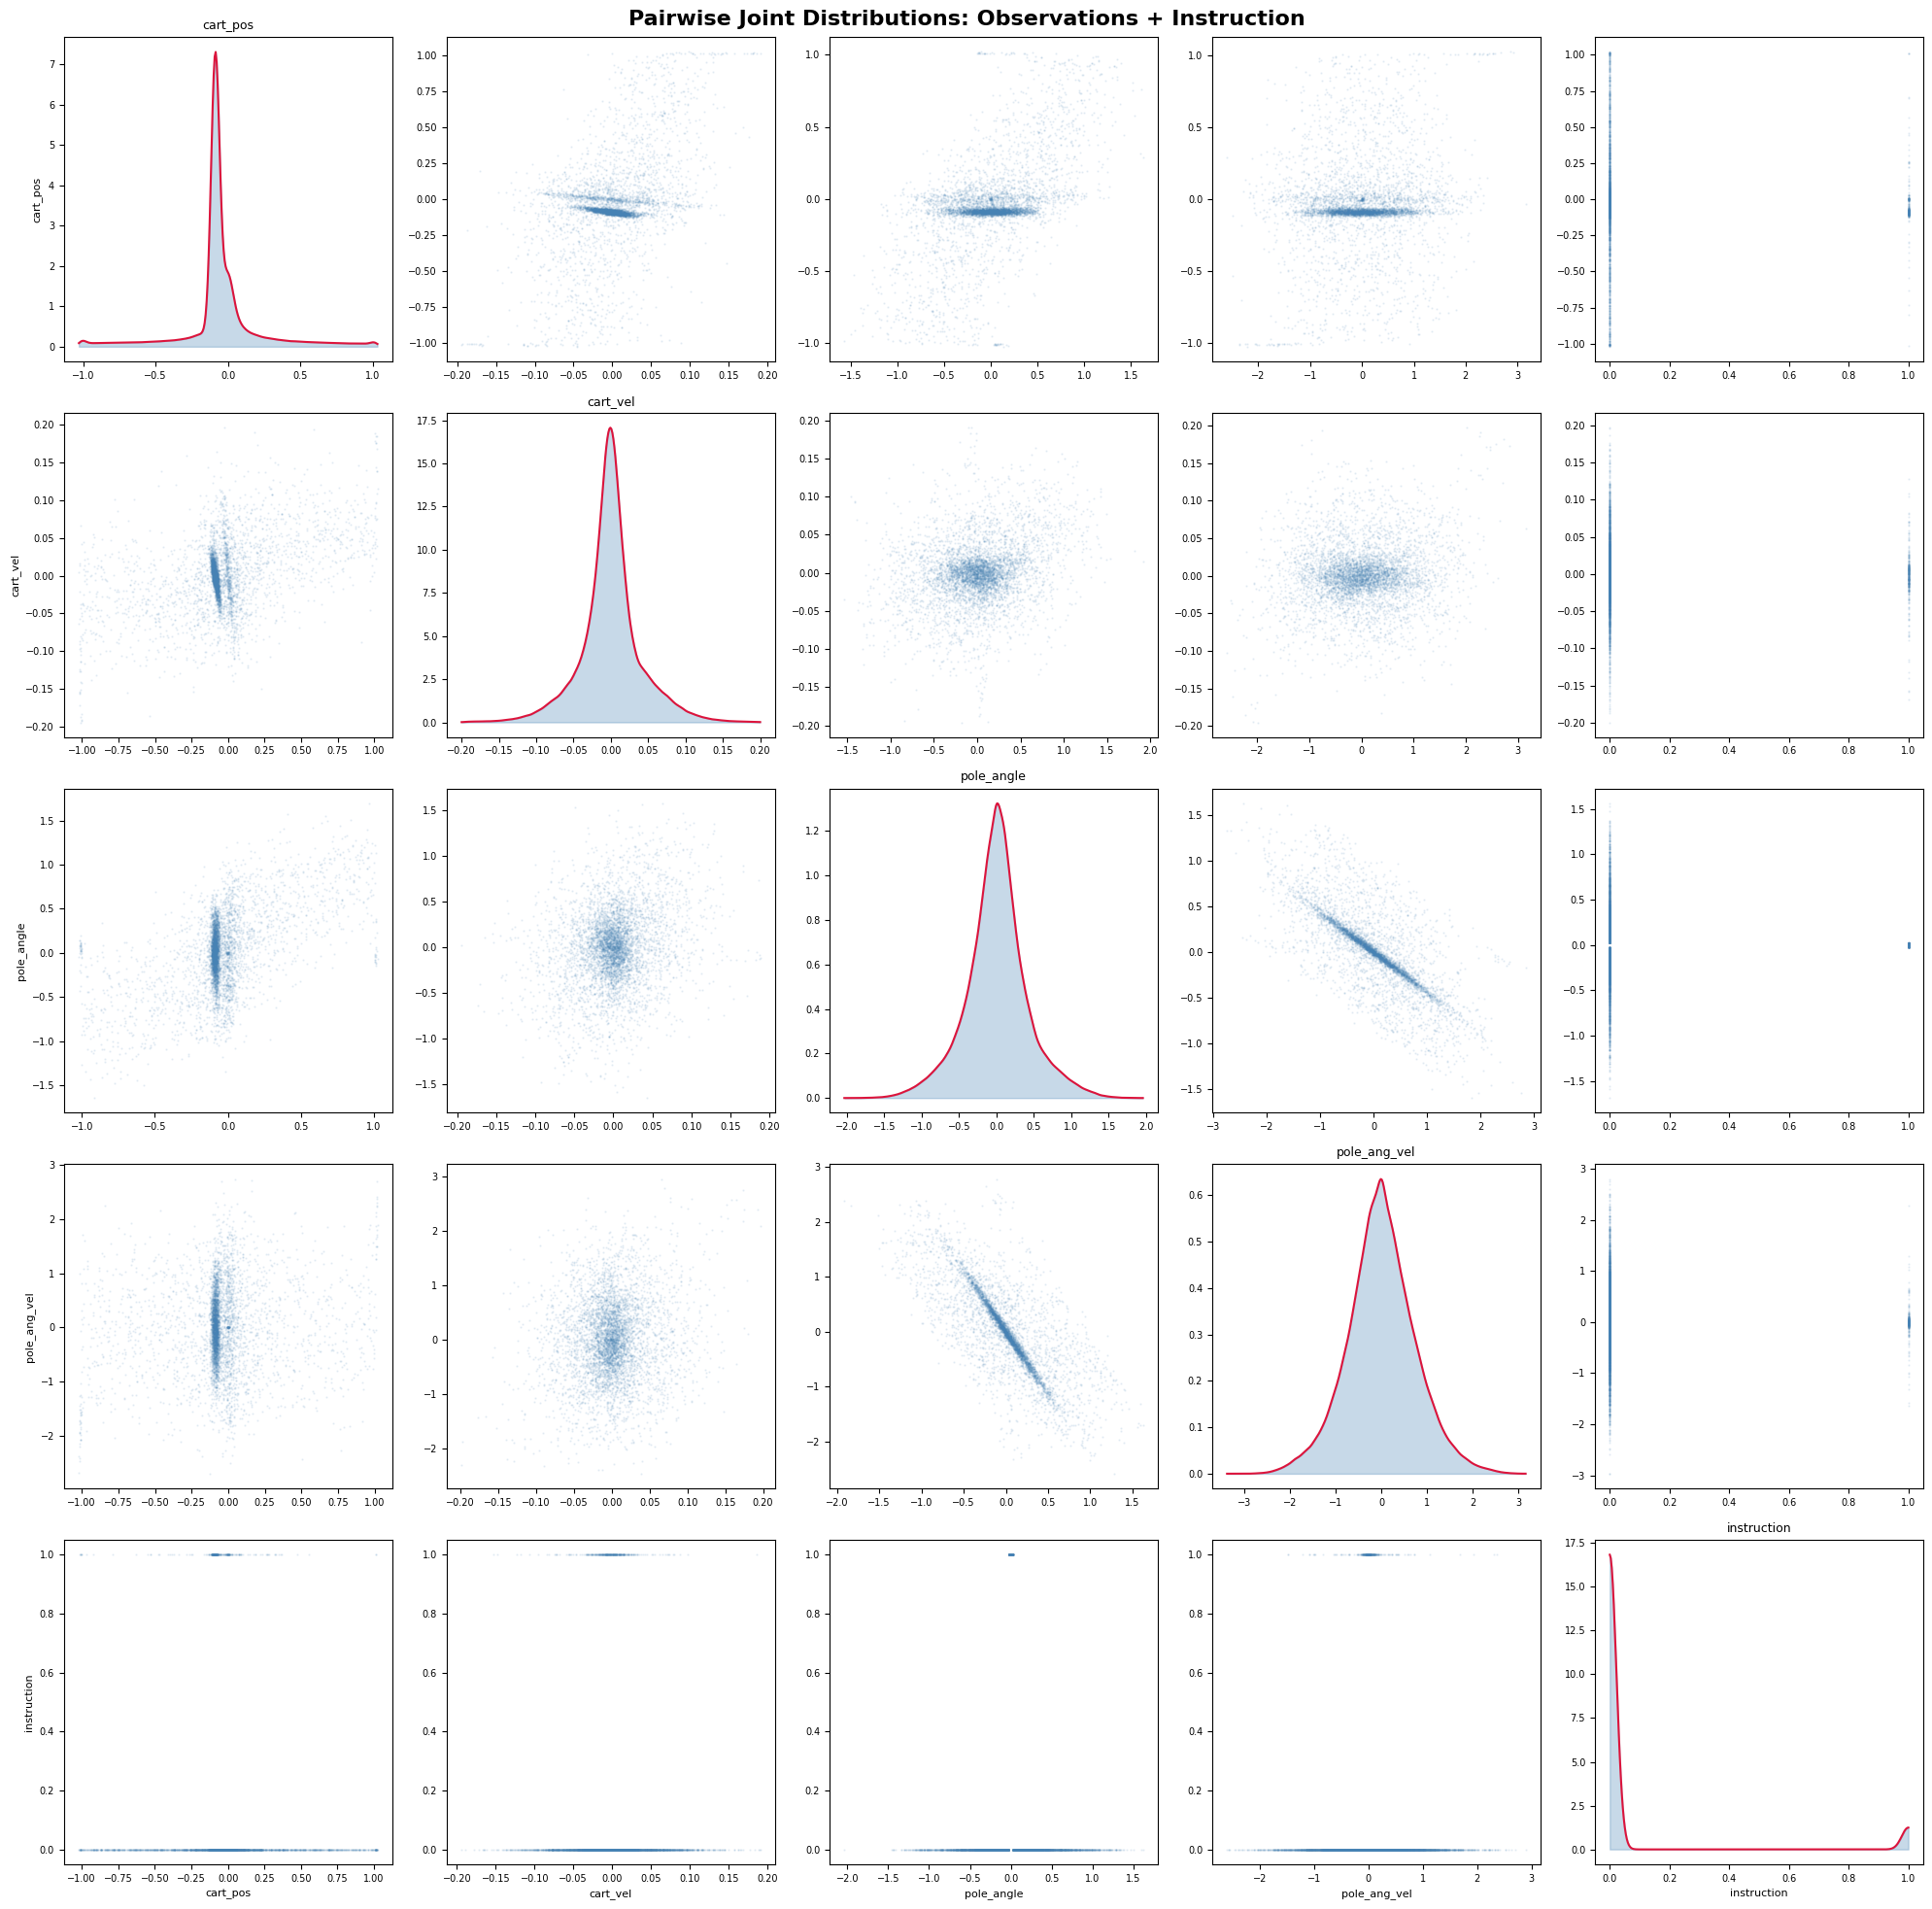

In [21]:
# Combine observations and instruction into a single matrix
all_obs_with_instruction = np.concatenate([all_observations, instruction], axis=1)
COL_NAMES_5 = ["cart_pos", "cart_vel", "pole_angle", "pole_ang_vel", "instruction"]

fig, axes = plt.subplots(5, 5, figsize=(20, 20))

for i in range(5):
    for j in range(5):
        ax = axes[i, j]
        if i == j:
            col = all_obs_with_instruction[:, i]
            kde = gaussian_kde(col)
            x = np.linspace(col.min(), col.max(), 300)
            ax.plot(x, kde(x), color="crimson")
            ax.fill_between(x, kde(x), alpha=0.3, color="steelblue")
            ax.set_title(COL_NAMES_5[i], fontsize=9)
        else:
            # Subsample for performance
            idx = np.random.choice(len(all_obs_with_instruction), size=5000, replace=False)
            ax.scatter(
                all_obs_with_instruction[idx, j],
                all_obs_with_instruction[idx, i],
                s=0.5, alpha=0.1, color="steelblue"
            )
        if i == 4:
            ax.set_xlabel(COL_NAMES_5[j], fontsize=8)
        if j == 0:
            ax.set_ylabel(COL_NAMES_5[i], fontsize=8)
        ax.tick_params(labelsize=7)

plt.suptitle("Pairwise Joint Distributions: Observations + Instruction", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## Initialize Critic SOM weights/prototypes

In [7]:
# prototype weights
W_crit = np.random.uniform(-1.0, 1.0, size=(11, 11, 4))

# post-synaptic activations
M_crit = np.zeros((11, 11))

## Initialize Sensor SOM weights/prototypes

In [8]:
# prototype weights
W_sensory = np.random.uniform(-1.0, 1.0, size=(11, 11, 4))

# post-synaptic activations
M_sensory = np.zeros((11, 11))

## Sensory SOM Update Algorithm

In [9]:
def update_sensorysom(observation, W, M, lr, sigma):
    """
    Update Sensory SOM weights and post-synaptic map.

    Parameters
    ----------
    observation : np.ndarray, shape (1, 4) or (4,)
    W           : np.ndarray, shape (11, 11, 4)
    M           : np.ndarray, shape (11, 11)
    lr          : scalar
    sigma       : scalar

    Returns
    -------
    W, M, bmu : updated arrays and BMU index tuple
    """
    # reshape observation to (4,) if it's (1, 4)
    x = np.asarray(observation).reshape(-1)
    if x.shape[0] != W.shape[2]:
        raise ValueError(f"Observation dimension {x.shape[0]} does not match W.shape[2]={W.shape[2]}.")

    dists = np.linalg.norm(W - x, axis=2)
    bmu = np.unravel_index(np.argmin(dists), dists.shape)

    # Gaussian neighborhood around BMU
    ii, jj = np.indices(M.shape)
    dist2 = (ii - bmu[0])**2 + (jj - bmu[1])**2
    h = np.exp(-dist2 / (2.0 * (float(sigma) ** 2)))

    # Store post-synaptic activation map
    M[:, :] = h

    # SOM weight update
    W[:, :, :] += float(lr) * h[:, :, None] * (x[None, None, :] - W)

    return W, M, bmu

## Critic SOM Update Algorithm

In [10]:
def update_critsom(observation, W, M, instruction, lr, sigma):
    """
    Update critic SOM weights and post-synaptic map.

    Parameters
    ----------
    observation : np.ndarray, shape (1, 4) or (4,)
    W           : np.ndarray, shape (11, 11, 4)
    M           : np.ndarray, shape (11, 11)
    instruction  : scalar
    lr          : scalar
    sigma       : scalar

    Returns
    -------
    W, M, bmu : updated arrays and BMU index tuple
    """
    x = np.asarray(observation).reshape(-1)
    if x.shape[0] != W.shape[2]:
        raise ValueError(f"Observation dimension {x.shape[0]} does not match W.shape[2]={W.shape[2]}.")

    # 1) Forced BMU at center when instruction == 1.0
    if np.isclose(instruction, 1.0):
        bmu = (5, 5)

    # 2) Normal SOM BMU when instruction != 0
    else:
        dists = np.linalg.norm(W - x, axis=2)
        bmu = np.unravel_index(np.argmin(dists), dists.shape)


    # Gaussian neighborhood around BMU
    ii, jj = np.indices(M.shape)
    dist2 = (ii - bmu[0])**2 + (jj - bmu[1])**2
    h = np.exp(-dist2 / (2.0 * (float(sigma) ** 2)))

    # Store post-synaptic activation map
    M[:, :] = h

    # SOM weight update
    W[:, :, :] += float(lr) * h[:, :, None] * (x[None, None, :] - W)

    return W, M, bmu

## Critic SOM Training Loop Function

In [11]:
def train_critsom(training_observations, lr, sigma, training_instruction, num_episodes, W_crit, M_crit, tau):
    base_observations = training_observations
    base_instruction = training_instruction
    
    # Treat one full pass over all rows as one episode, then stack episodes
    observations_set = np.tile(base_observations, (num_episodes, 1))
    instruction_set = np.tile(base_instruction, (num_episodes, 1))

    for idx, (obs_row, inst_row) in enumerate(zip(observations_set, instruction_set), start=1):
        inst_scalar = float(inst_row[0])
        current_lr = lr * np.exp(-idx / tau)
        current_sigma = sigma * np.exp(-idx / tau)
        W_crit, M_crit, bmu = update_critsom(obs_row, W_crit, M_crit, inst_scalar, current_lr, current_sigma)

    return W_crit, M_crit, bmu


## Sensory SOM Training Loop Function

In [12]:
# trainin_observations is considered one episode, and we repeat for num_episodes
def train_sensorysom(training_observations, lr, sigma, num_episodes, W_sensory, M_sensory, tau):
    sensory_observations_set = np.tile(training_observations, (num_episodes, 1))

    for sensory_idx, sensory_obs_row in enumerate(sensory_observations_set, start=1):
        current_lr = lr * np.exp(-sensory_idx / tau)
        current_sigma = sigma * np.exp(-sensory_idx / tau)
        W_sensory, M_sensory, sensory_bmu = update_sensorysom(
            sensory_obs_row, W_sensory, M_sensory, current_lr, current_sigma
        )

    return W_sensory, M_sensory, sensory_bmu


## Training/Testing Data Splitting Function

In [13]:
# 80/20 train-test split is the default, but we can adjust the split ratio if desired
def train_test_split(all_observations, instruction, split_ratio=0.8):
    split_idx = int(len(all_observations) * split_ratio)
    shuffled_idx = np.random.permutation(len(all_observations))
    training_idx = shuffled_idx[:split_idx]
    testing_idx = shuffled_idx[split_idx:]
    return (
        all_observations[training_idx],
        all_observations[testing_idx],
        instruction[training_idx],
        instruction[testing_idx]
    )

## Train & Test "Perception SOMs" (Sensor SOM & Critic SOM)

Training complete.


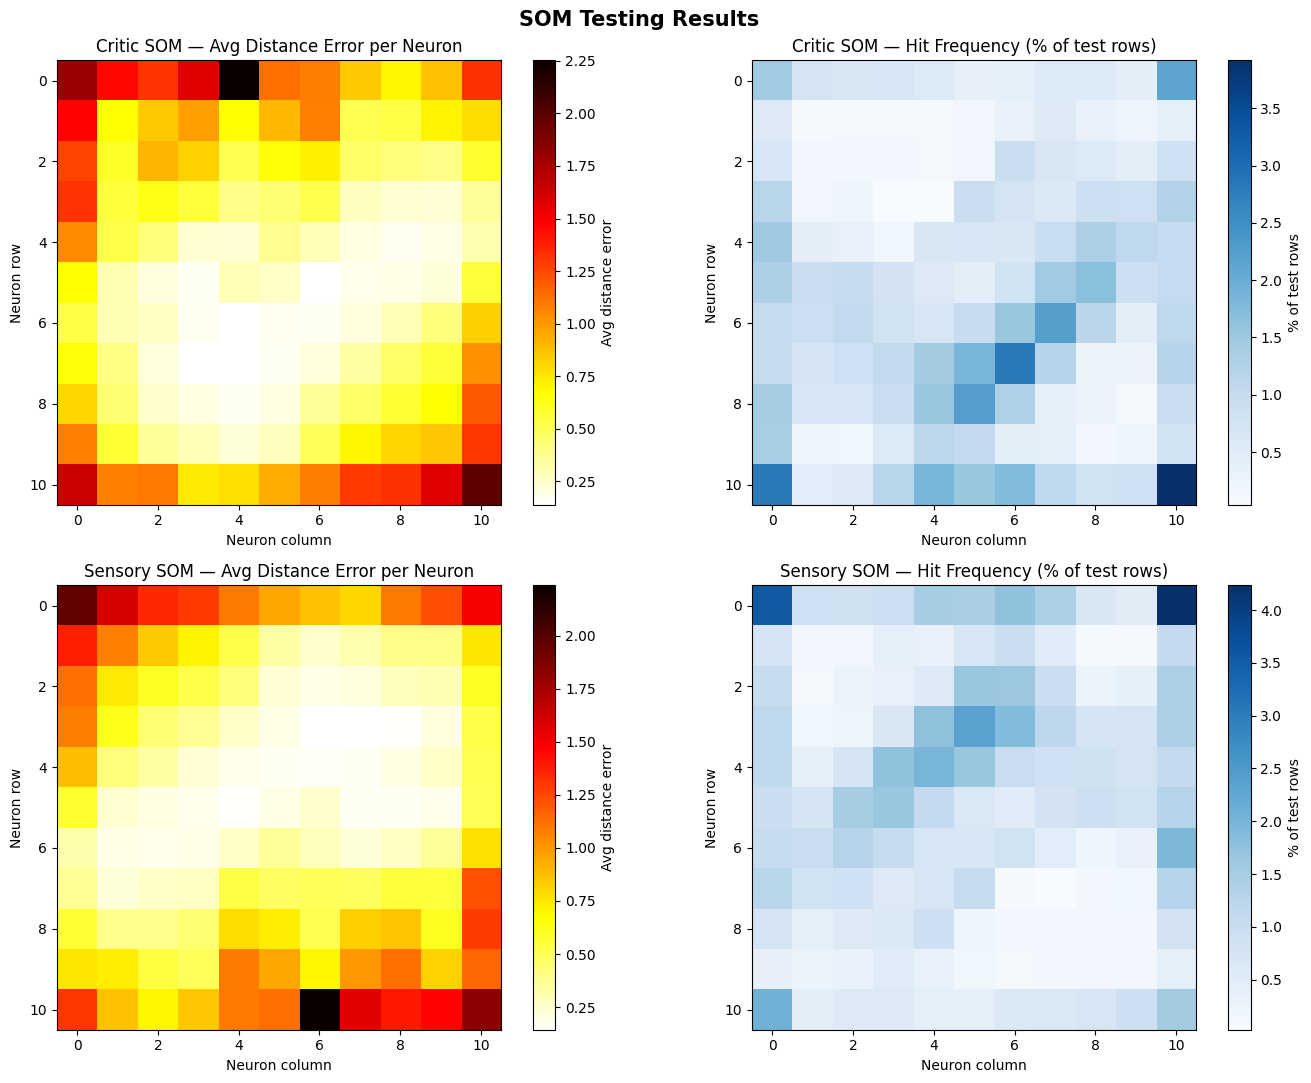

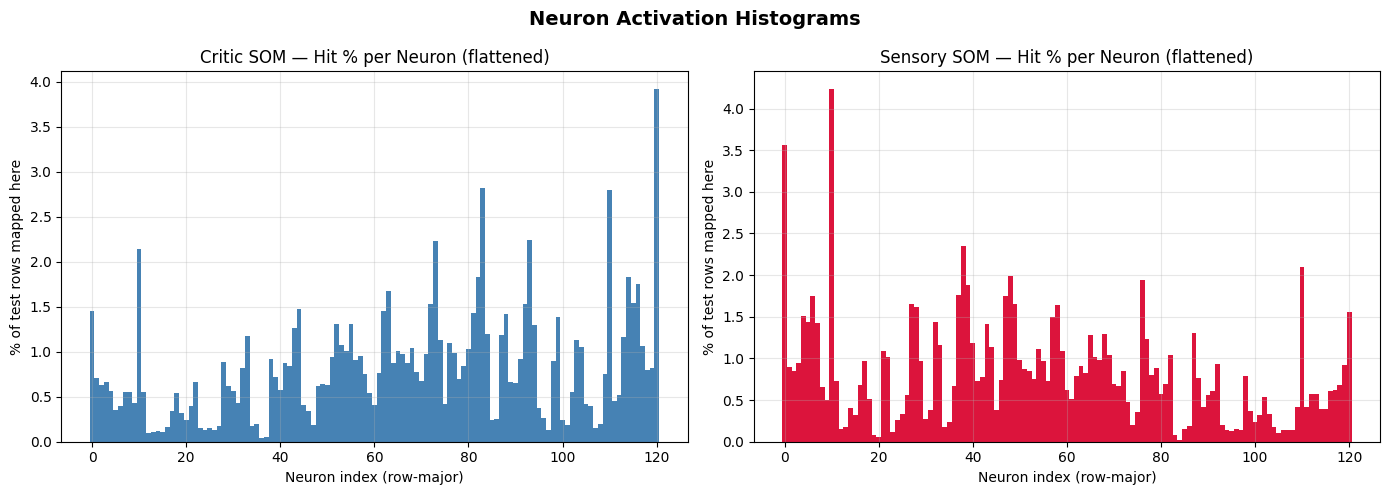


Test rows: 19908
Critic    — neurons hit: 121/121, mean avg error: 0.6376
Sensory   — neurons hit: 121/121, mean avg error: 0.6317

Critic SOM — center-neuron (5,5) accuracy when instruction=1.0:
  14/1337 correct (1.05%)


In [19]:

# --- Split data ---
training_observations, testing_observations, training_instruction, testing_instruction = train_test_split(
    scaled_observations, instruction, split_ratio=0.9
)

# --- Reinitialize weights (fresh training) ---
W_crit    = np.random.uniform(-1.0, 1.0, size=(11, 11, 4))
M_crit    = np.zeros((11, 11))
W_sensory = np.random.uniform(-1.0, 1.0, size=(11, 11, 4))
M_sensory = np.zeros((11, 11))

# --- Train ---
lr, sigma, num_episodes = 0.5, 5.0, 3
T = num_episodes * len(training_observations)
tau = T   # decays to ~5% of initial by the last step

W_crit, M_crit, _ = train_critsom(
    training_observations, lr, sigma, training_instruction, num_episodes, W_crit, M_crit, tau
)
W_sensory, M_sensory, _ = train_sensorysom(
    training_observations, lr, sigma, num_episodes, W_sensory, M_sensory, tau

)
print("Training complete.")

# -------------------------------------------------------------------
# Testing: map each test row to its BMU and accumulate stats
# -------------------------------------------------------------------
grid = (11, 11)

crit_error_sum    = np.zeros(grid)
crit_hit_count    = np.zeros(grid, dtype=int)
sensory_error_sum = np.zeros(grid)
sensory_hit_count = np.zeros(grid, dtype=int)

# Critic center-neuron accuracy: how often BMU == (5,5) when instruction == 1.0
crit_center_total = 0
crit_center_hits  = 0

for obs_row, inst_row in zip(testing_observations, testing_instruction):
    x = obs_row

    # Critic BMU & error
    dists = np.linalg.norm(W_crit - x, axis=2)
    bmu_c = np.unravel_index(np.argmin(dists), dists.shape)
    crit_error_sum[bmu_c]  += dists[bmu_c]
    crit_hit_count[bmu_c]  += 1

    # Track center-neuron accuracy for instruction == 1.0
    if np.isclose(float(inst_row[0]), 1.0):
        crit_center_total += 1
        if bmu_c == (5, 5):
            crit_center_hits += 1

    # Sensory BMU & error
    dists = np.linalg.norm(W_sensory - x, axis=2)
    bmu_s = np.unravel_index(np.argmin(dists), dists.shape)
    sensory_error_sum[bmu_s]  += dists[bmu_s]
    sensory_hit_count[bmu_s]  += 1

n_test = len(testing_observations)

# Average distance error per neuron (avoid divide-by-zero)
crit_avg_error    = np.where(crit_hit_count > 0,    crit_error_sum    / np.maximum(crit_hit_count, 1),    np.nan)
sensory_avg_error = np.where(sensory_hit_count > 0, sensory_error_sum / np.maximum(sensory_hit_count, 1), np.nan)

# Hit frequency as % of test rows
crit_hit_pct    = crit_hit_count    / n_test * 100.0
sensory_hit_pct = sensory_hit_count / n_test * 100.0

# -------------------------------------------------------------------
# Visualizations
# -------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# -- Critic: avg distance error heatmap --
ax = axes[0, 0]
im = ax.imshow(crit_avg_error, cmap="hot_r", origin="upper")
fig.colorbar(im, ax=ax, label="Avg distance error")
ax.set_title("Critic SOM — Avg Distance Error per Neuron", fontsize=12)
ax.set_xlabel("Neuron column")
ax.set_ylabel("Neuron row")

# -- Critic: hit-frequency heatmap --
ax = axes[0, 1]
im = ax.imshow(crit_hit_pct, cmap="Blues", origin="upper")
fig.colorbar(im, ax=ax, label="% of test rows")
ax.set_title("Critic SOM — Hit Frequency (% of test rows)", fontsize=12)
ax.set_xlabel("Neuron column")
ax.set_ylabel("Neuron row")

# -- Sensory: avg distance error heatmap --
ax = axes[1, 0]
im = ax.imshow(sensory_avg_error, cmap="hot_r", origin="upper")
fig.colorbar(im, ax=ax, label="Avg distance error")
ax.set_title("Sensory SOM — Avg Distance Error per Neuron", fontsize=12)
ax.set_xlabel("Neuron column")
ax.set_ylabel("Neuron row")

# -- Sensory: hit-frequency heatmap --
ax = axes[1, 1]
im = ax.imshow(sensory_hit_pct, cmap="Blues", origin="upper")
fig.colorbar(im, ax=ax, label="% of test rows")
ax.set_title("Sensory SOM — Hit Frequency (% of test rows)", fontsize=12)
ax.set_xlabel("Neuron column")
ax.set_ylabel("Neuron row")

plt.suptitle("SOM Testing Results", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# Histograms: distribution of hits across flattened neuron indices
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(range(121), crit_hit_pct.flatten(), color="steelblue", width=1.0)
ax.set_title("Critic SOM — Hit % per Neuron (flattened)", fontsize=12)
ax.set_xlabel("Neuron index (row-major)")
ax.set_ylabel("% of test rows mapped here")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.bar(range(121), sensory_hit_pct.flatten(), color="crimson", width=1.0)
ax.set_title("Sensory SOM — Hit % per Neuron (flattened)", fontsize=12)
ax.set_xlabel("Neuron index (row-major)")
ax.set_ylabel("% of test rows mapped here")
ax.grid(True, alpha=0.3)

plt.suptitle("Neuron Activation Histograms", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nTest rows: {n_test}")
print(f"Critic    — neurons hit: {(crit_hit_count > 0).sum()}/121, "
      f"mean avg error: {np.nanmean(crit_avg_error):.4f}")
print(f"Sensory   — neurons hit: {(sensory_hit_count > 0).sum()}/121, "
      f"mean avg error: {np.nanmean(sensory_avg_error):.4f}")

# -------------------------------------------------------------------
# Critic center-neuron accuracy (instruction == 1.0 → BMU should be (5,5))
# -------------------------------------------------------------------
if crit_center_total > 0:
    crit_center_acc = crit_center_hits / crit_center_total * 100.0
    print(f"\nCritic SOM — center-neuron (5,5) accuracy when instruction=1.0:")
    print(f"  {crit_center_hits}/{crit_center_total} correct ({crit_center_acc:.2f}%)")
else:
    print("\nCritic SOM — no test rows with instruction=1.0")


In [20]:
import itertools

# -------------------------------------------------------------------
# Hyperparameter grid — Critic SOM center-neuron accuracy sweep
# Maximize: % of test rows with instruction=1.0 that map to BMU (5,5)
# -------------------------------------------------------------------
lr_values         = [0.1, 0.3, 0.5, 0.7]
sigma_values      = [2.0, 3.0, 5.0]
num_episodes_vals = [1, 3, 5]
tau_factor_vals   = [1, 3]        # tau = T / tau_factor

combos = list(itertools.product(lr_values, sigma_values, num_episodes_vals, tau_factor_vals))
print(f"Total combinations to evaluate: {len(combos)}\n")

best_acc    = -1.0
best_params = None
results     = []

for i, (lr_, sigma_, num_ep_, tau_f_) in enumerate(combos, start=1):
    W_c = np.random.uniform(-1.0, 1.0, size=(11, 11, 4))
    M_c = np.zeros((11, 11))

    T_   = num_ep_ * len(training_observations)
    tau_ = T_ / tau_f_

    W_c, M_c, _ = train_critsom(
        training_observations, lr_, sigma_, training_instruction,
        num_ep_, W_c, M_c, tau_
    )

    # Evaluate: how often does the critic map instruction=1.0 inputs to (5,5)?
    center_total = 0
    center_hits  = 0
    for obs_row, inst_row in zip(testing_observations, testing_instruction):
        if not np.isclose(float(inst_row[0]), 1.0):
            continue
        center_total += 1
        dists = np.linalg.norm(W_c - obs_row, axis=2)
        bmu = np.unravel_index(np.argmin(dists), dists.shape)
        if bmu == (5, 5):
            center_hits += 1

    acc = (center_hits / center_total * 100.0) if center_total > 0 else 0.0
    results.append((acc, lr_, sigma_, num_ep_, tau_f_))

    if acc > best_acc:
        best_acc    = acc
        best_params = (lr_, sigma_, num_ep_, tau_f_)

    if i % 10 == 0 or i == len(combos):
        print(f"  [{i:>3}/{len(combos)}] lr={lr_:.2f}  sigma={sigma_:.1f}  "
              f"episodes={num_ep_}  tau_factor={tau_f_}  →  {acc:.2f}%")

# -------------------------------------------------------------------
# Results summary
# -------------------------------------------------------------------
results.sort(reverse=True)
print(f"\n{'─'*58}")
print(f"Top 10 configurations (Critic SOM — center-neuron accuracy)")
print(f"{'─'*58}")
print(f"{'Acc':>8}  {'lr':>6}  {'sigma':>6}  {'episodes':>9}  {'tau_factor':>10}")
print(f"{'─'*58}")
for acc, lr_, sigma_, num_ep_, tau_f_ in results[:10]:
    marker = " ◀ best" if (lr_, sigma_, num_ep_, tau_f_) == best_params else ""
    print(f"{acc:>7.2f}%  {lr_:>6.2f}  {sigma_:>6.1f}  {num_ep_:>9}  {tau_f_:>10}{marker}")

lr_, sigma_, num_ep_, tau_f_ = best_params
print(f"\nBest params:  lr={lr_}  sigma={sigma_}  num_episodes={num_ep_}  tau_factor={tau_f_}")
print(f"Best accuracy: {best_acc:.2f}%  ({int(best_acc/100 * center_total)}/{center_total} test rows with instruction=1.0)")


Total combinations to evaluate: 72

  [ 10/72] lr=0.10  sigma=3.0  episodes=3  tau_factor=3  →  30.74%
  [ 20/72] lr=0.30  sigma=2.0  episodes=1  tau_factor=3  →  37.62%
  [ 30/72] lr=0.30  sigma=3.0  episodes=5  tau_factor=3  →  38.00%
  [ 40/72] lr=0.50  sigma=2.0  episodes=3  tau_factor=3  →  44.50%
  [ 50/72] lr=0.50  sigma=5.0  episodes=1  tau_factor=3  →  20.27%
  [ 60/72] lr=0.70  sigma=2.0  episodes=5  tau_factor=3  →  41.21%
  [ 70/72] lr=0.70  sigma=5.0  episodes=3  tau_factor=3  →  35.30%
  [ 72/72] lr=0.70  sigma=5.0  episodes=5  tau_factor=3  →  37.77%

──────────────────────────────────────────────────────────
Top 10 configurations (Critic SOM — center-neuron accuracy)
──────────────────────────────────────────────────────────
     Acc      lr   sigma   episodes  tau_factor
──────────────────────────────────────────────────────────
  44.50%    0.50     2.0          3           3 ◀ best
  44.35%    0.30     2.0          3           3
  42.93%    0.70     2.0          3    